# Predicción del abandono de clientes (Churn) en telecomunicaciones
**Fase 1 – Modelo predictivo | Modelos y Simulación de Sistemas I**

> Rama `feature/analisis-exploratorio`: este bloque cubre las secciones 1 a 3 (introducción, descripción y exploración).
> Las secciones de preparación, separación, modelo base, modelo predictivo y almacenamiento se agregan en sus ramas respectivas.

## 1. Introducción
- **Problema:** las empresas de telecomunicaciones pierden clientes (*customer churn*). Identificarlos con anticipación permite actuar con estrategias de retención.
- **Objetivo del modelo:** predecir si un cliente abandonará (`Yes`) o continuará (`No`) a partir de sus características.
- **Tipo de problema:** aprendizaje supervisado, clasificación binaria sobre registros independientes (no es una serie de tiempo).
- **Variable objetivo:** `Churn` (`Yes` = abandonó, `No` = permaneció).
- **Fuente:** [IBM Telco Customer Churn – Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn).

In [21]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from IPython.display import display

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)

# Ruta al CSV (ajustar si el archivo está en otra carpeta)
DATA_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
TARGET = "Churn"

## 2. Descripción del conjunto de datos

In [22]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()   # df_raw se conserva intacto como referencia
print(f"Observaciones: {df.shape[0]:,} | Variables: {df.shape[1]}")
df.head()

Observaciones: 7,043 | Variables: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Descripción general**

| Grupo | Variables |
|---|---|
| Identificador (no se usará como predictora) | `customerID` |
| Demográficas | `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| Servicios contratados | `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` |
| Cuenta y facturación | `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges` |
| **Objetivo** | `Churn` |

**Posibles limitaciones:** conjunto pequeño (~7 mil clientes) y de una sola empresa, es una foto estática (sin historial mensual), la clase objetivo está desbalanceada y no incluye información de precios de la competencia ni de interacciones con soporte, que suelen influir en el abandono.

## 3. Exploración de los datos
### 3.1 Dimensiones, tipos de variables e integridad

In [23]:
print("Dimensiones:", df.shape)
print("Duplicados completos:", df.duplicated().sum())
print("customerID únicos:", df["customerID"].nunique(), "de", len(df))
df.dtypes.to_frame("dtype").T

Dimensiones: (7043, 21)
Duplicados completos: 0
customerID únicos: 7043 de 7043


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
dtype,str,str,int64,str,str,int64,str,str,str,str,str,str,str,str,str,str,str,str,float64,str,str


`TotalCharges` debería ser numérica, pero aparece como texto (`object`) por celdas vacías. Se convierte a numérico **solo para poder explorarla**: es una corrección de tipo, no aprende nada de los datos, por lo que no genera fuga de información. La imputación se hará en preprocesamiento, ajustada solo con entrenamiento.

In [24]:
# Celdas "vacías" (espacios) que impiden la conversión
vacios = df["TotalCharges"].astype(str).str.strip().eq("").sum()
print("Celdas vacías en TotalCharges:", vacios)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})  # es categórica codificada como 0/1

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in df.columns if c not in num_cols + ["customerID", TARGET]]
print("Numéricas:", num_cols)
print(f"Categóricas ({len(cat_cols)}):", cat_cols)

Celdas vacías en TotalCharges: 11
Numéricas: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categóricas (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 3.2 Valores faltantes

In [25]:
faltantes = pd.DataFrame({
    "n_faltantes": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(3),
})
faltantes = faltantes[faltantes["n_faltantes"] > 0]
display(faltantes)

filas_nan = df[df["TotalCharges"].isna()]
print("\nFilas con TotalCharges faltante:", len(filas_nan))
display(filas_nan[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", TARGET]])

,n_faltantes,porcentaje
TotalCharges,11,0.156



Filas con TotalCharges faltante: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,NaN,Two year,No
753,3115-CZMZD,0,20.25,NaN,Two year,No
936,5709-LVOEQ,0,80.85,NaN,Two year,No
1082,4367-NUYAO,0,25.75,NaN,Two year,No
1340,1371-DWPAZ,0,56.05,NaN,Two year,No
3331,7644-OMVMY,0,19.85,NaN,Two year,No
3826,3213-VVOLG,0,25.35,NaN,Two year,No
4380,2520-SGTTA,0,20.00,NaN,Two year,No
5218,2923-ARZLG,0,19.70,NaN,One year,No
6670,4075-WKNIU,0,73.35,NaN,Two year,No


**Lectura:** `TotalCharges` es la única variable con faltantes (11 de 7.043 registros ≈ 0,156 %, dentro del rango 0,1 %–2 % exigido). Todas esas filas tienen `tenure = 0`, es decir, clientes recién registrados que aún no han recibido su primera factura. **No es un faltante aleatorio: tiene significado**, ya que el total acumulado es 0 por construcción. Esto respalda una imputación con 0 (o una regla equivalente) en lugar de media/mediana, decisión que se formalizará en la rama de preprocesamiento. Además, ninguno de estos clientes abandonó (ver columna `Churn`), por lo que eliminarlos también sería viable pero descartaría información sin necesidad.

In [26]:
# Valores "ocultos": revisar categorías de cada variable categórica
for c in cat_cols:
    print(f"{c:18s}", sorted(df[c].dropna().unique()))

gender             ['Female', 'Male']
SeniorCitizen      ['No', 'Yes']
Partner            ['No', 'Yes']
Dependents         ['No', 'Yes']
PhoneService       ['No', 'Yes']
MultipleLines      ['No', 'No phone service', 'Yes']
InternetService    ['DSL', 'Fiber optic', 'No']
OnlineSecurity     ['No', 'No internet service', 'Yes']
OnlineBackup       ['No', 'No internet service', 'Yes']
DeviceProtection   ['No', 'No internet service', 'Yes']
TechSupport        ['No', 'No internet service', 'Yes']
StreamingTV        ['No', 'No internet service', 'Yes']
StreamingMovies    ['No', 'No internet service', 'Yes']
Contract           ['Month-to-month', 'One year', 'Two year']
PaperlessBilling   ['No', 'Yes']
PaymentMethod      ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']


Se observan las categorías `No internet service` y `No phone service`. No son faltantes: indican que el servicio base no existe y son redundantes con `InternetService` / `PhoneService`. Se dejan anotadas para decidir su tratamiento en preprocesamiento.

### 3.3 Estadísticas descriptivas

In [27]:
display(df[num_cols].describe().T.round(2))
display(df[cat_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75
TotalCharges,7032.0,2283.30,2266.77,18.80,401.45,1397.48,3794.74,8684.80


,count,unique,top,freq
gender,7043,2,Male,3555
SeniorCitizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


### 3.4 Distribución de la variable objetivo

,clientes,porcentaje
Churn,,
No,5174,73.46
Yes,1869,26.54


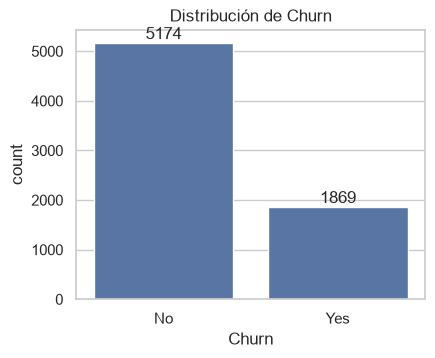

In [28]:
conteo = df[TARGET].value_counts()
pct = df[TARGET].value_counts(normalize=True).mul(100).round(2)
display(pd.DataFrame({"clientes": conteo, "porcentaje": pct}))

fig, ax = plt.subplots(figsize=(4.5, 3.5))
sns.countplot(data=df, x=TARGET, order=["No", "Yes"], ax=ax)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
ax.set_title("Distribución de Churn")
plt.show()

**Lectura:** la clase `Yes` representa aproximadamente una cuarta parte de los clientes. Existe **desbalance moderado**, por lo que `accuracy` sola sería engañosa (predecir siempre `No` daría ~73 %). Se recomienda separar con estratificación y evaluar con `recall`, `F1` y `ROC-AUC`.

### 3.5 Variables numéricas frente a Churn

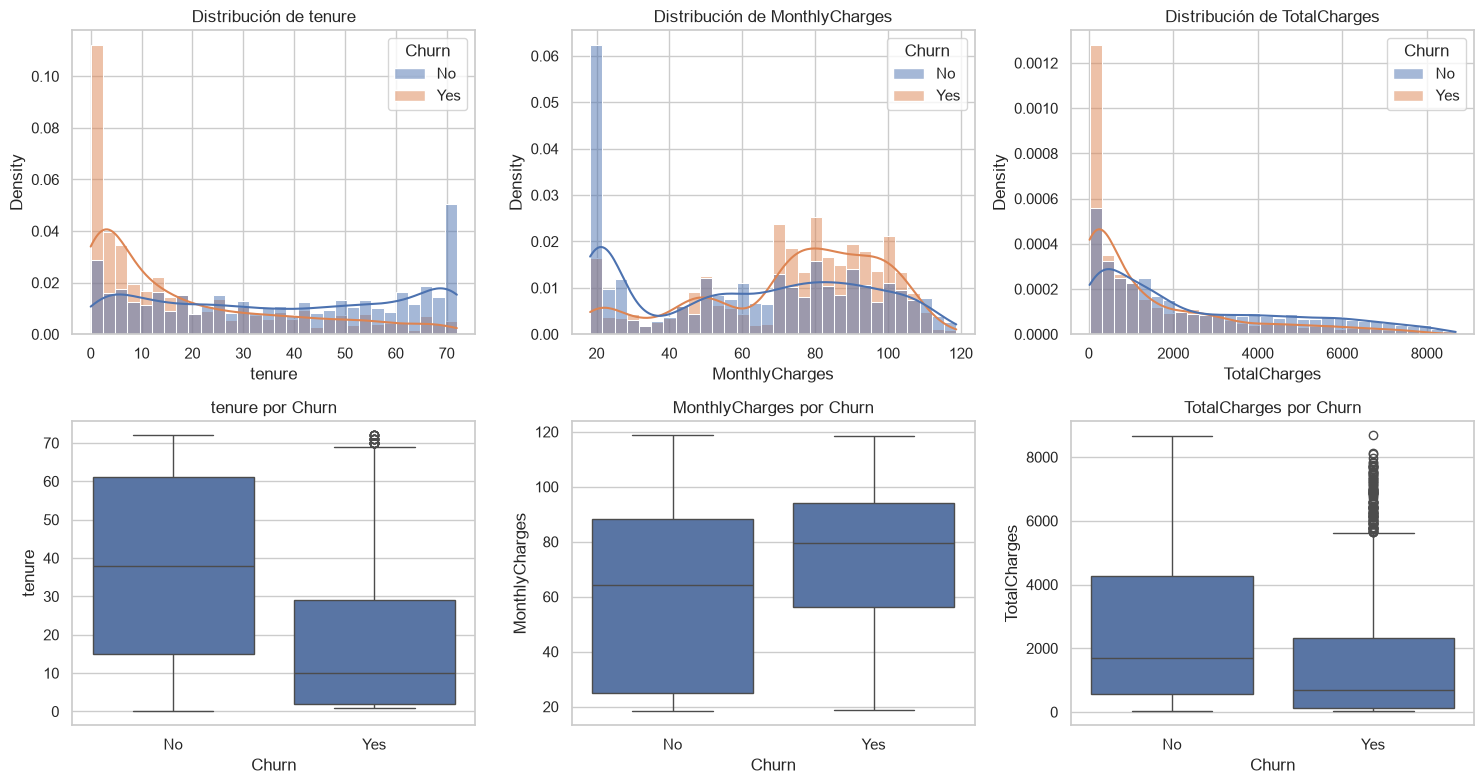

tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
No     37.57   38.0          61.27  64.43      2555.34  1683.60
Yes    17.98   10.0          74.44  79.65      1531.80   703.55

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, c in enumerate(num_cols):
    sns.histplot(data=df, x=c, hue=TARGET, bins=30, kde=True, stat="density",
                 common_norm=False, ax=axes[0, i])
    axes[0, i].set_title(f"Distribución de {c}")
    sns.boxplot(data=df, x=TARGET, y=c, order=["No", "Yes"], ax=axes[1, i])
    axes[1, i].set_title(f"{c} por Churn")
plt.tight_layout()
plt.show()

display(df.groupby(TARGET)[num_cols].agg(["mean", "median"]).round(2))

**Lectura:** los clientes que abandonan tienden a tener **menor antigüedad (`tenure`)** y **cargos mensuales más altos**, mientras que `TotalCharges` es menor porque han acumulado menos meses. La distribución de `tenure` es bimodal (muchos clientes nuevos y muchos muy antiguos).

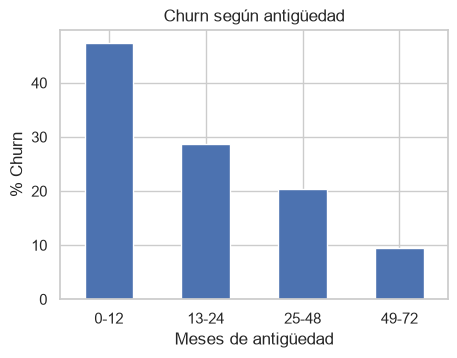

In [30]:
# Tasa de churn por tramos de antigüedad
tramos = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72], labels=["0-12", "13-24", "25-48", "49-72"])
tasa = df.groupby(tramos)[TARGET].apply(lambda s: (s == "Yes").mean() * 100)
ax = tasa.plot(kind="bar", figsize=(5, 3.5), rot=0)
ax.set_ylabel("% Churn"); ax.set_xlabel("Meses de antigüedad"); ax.set_title("Churn según antigüedad")
plt.show()

### 3.6 Variables categóricas frente a Churn

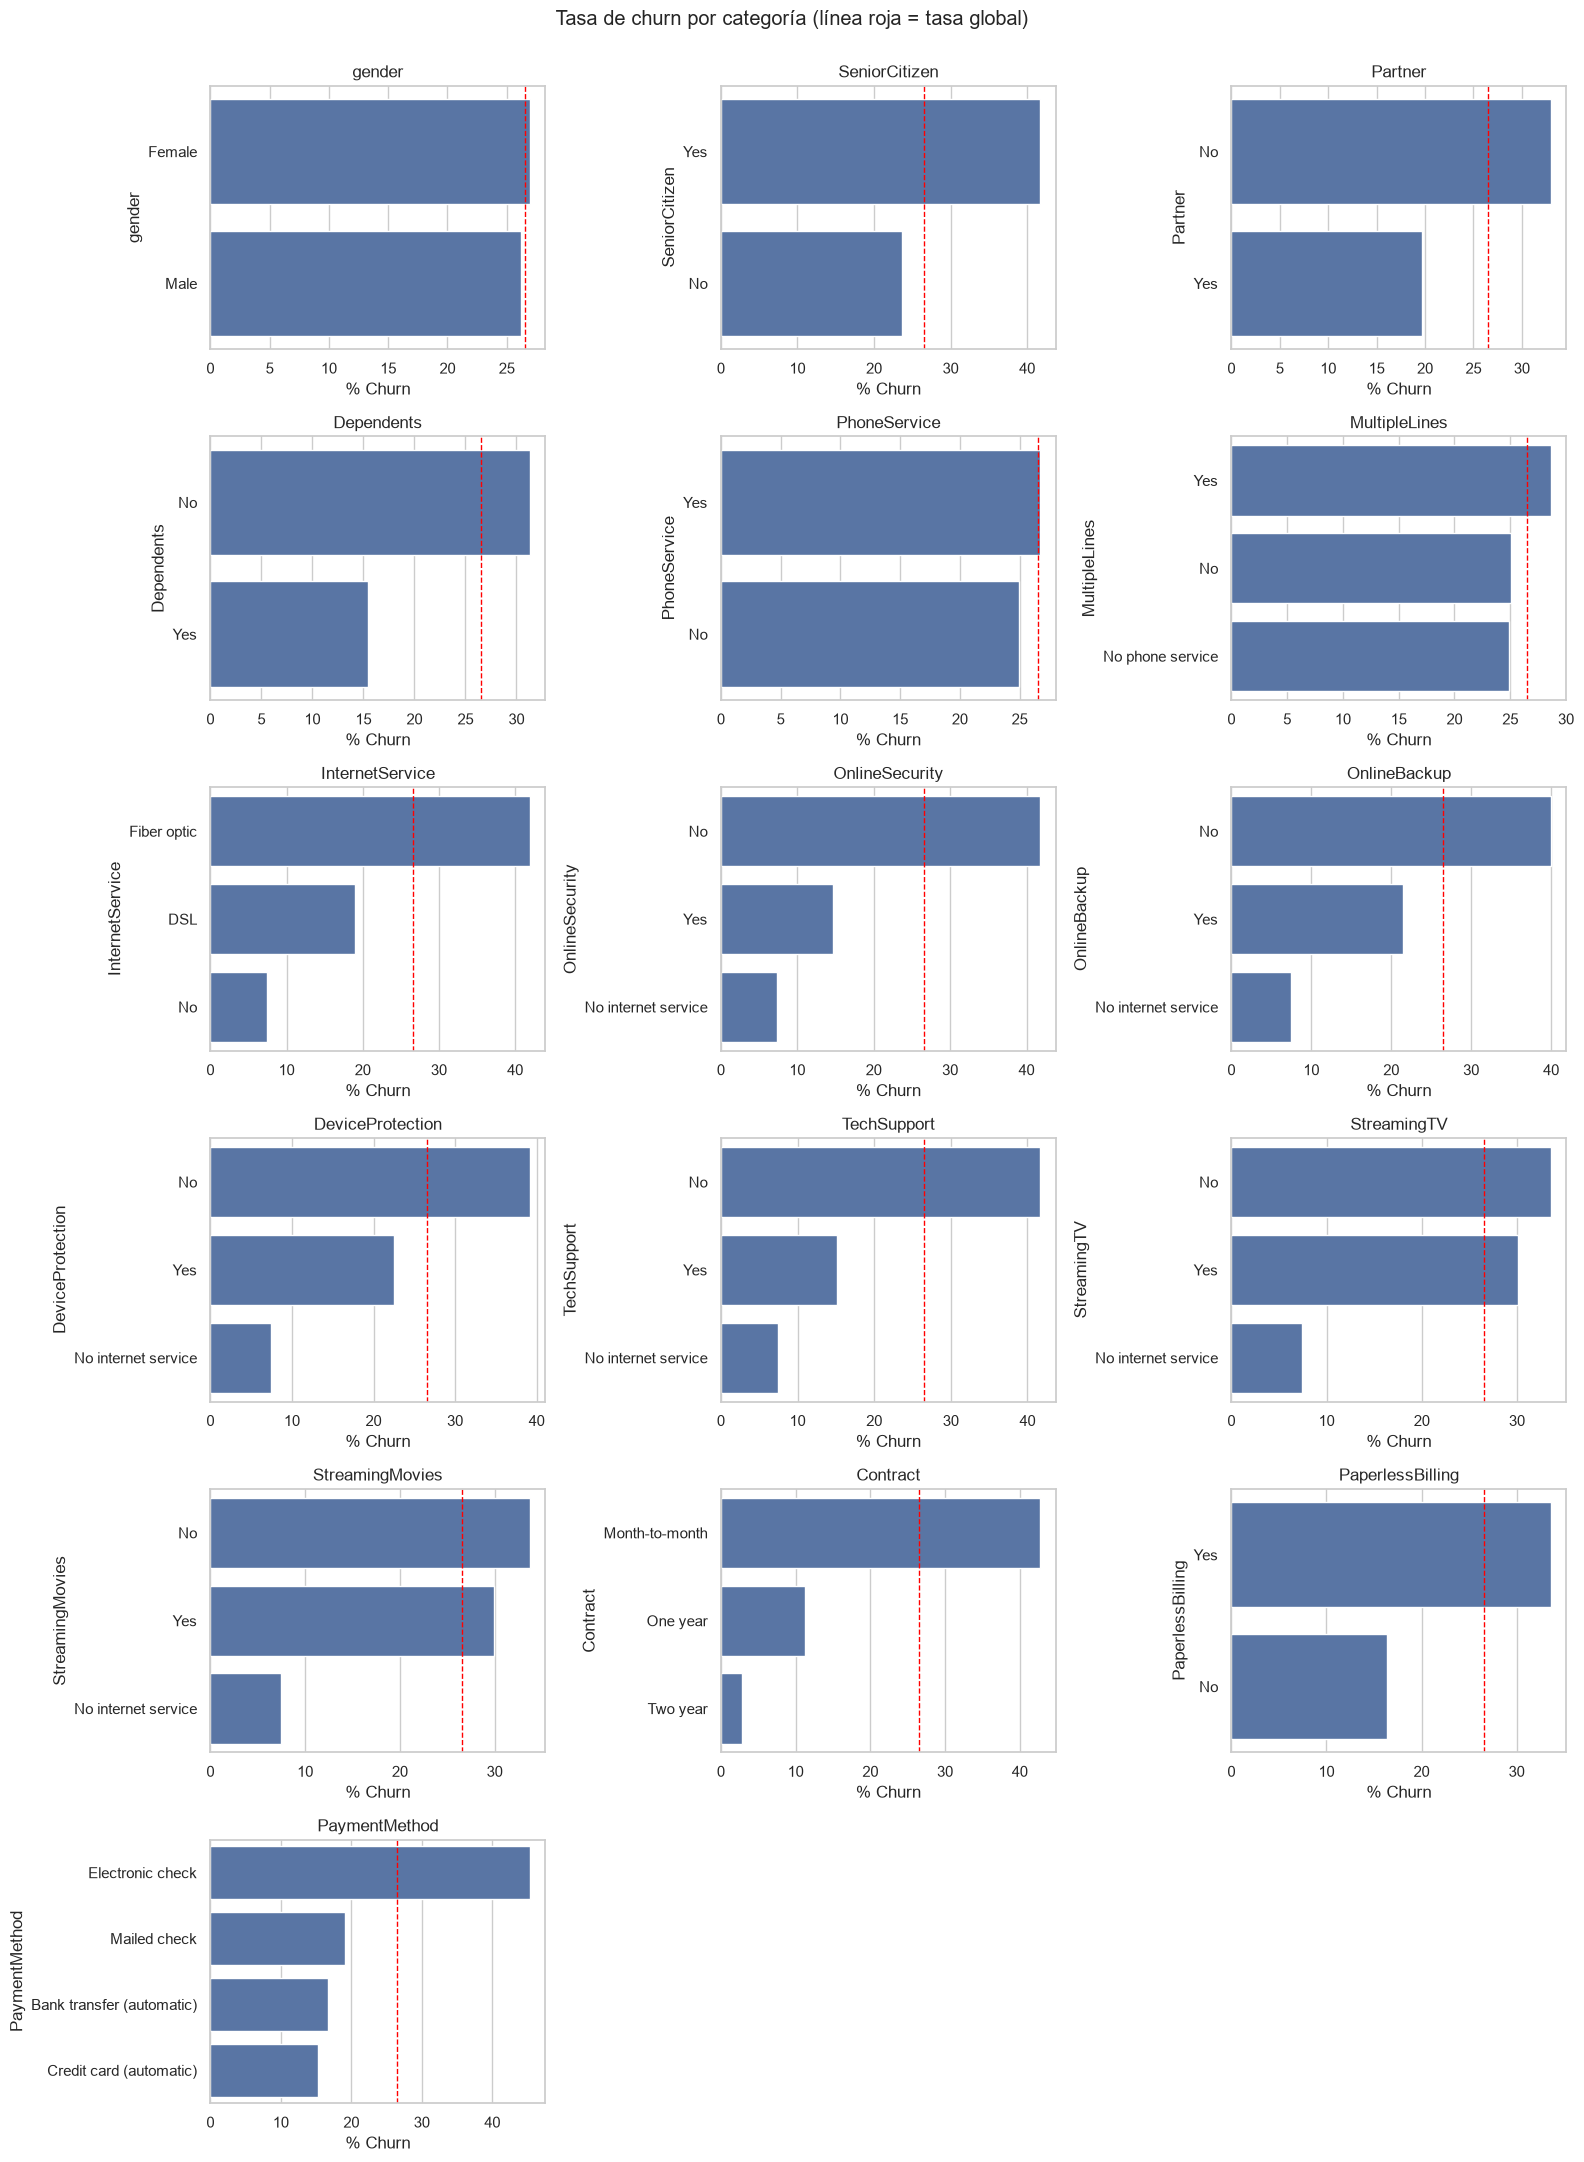

In [31]:
n = len(cat_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.6 * nrows))
axes = axes.ravel()
for ax, c in zip(axes, cat_cols):
    tasa = (df.groupby(c)[TARGET].apply(lambda s: (s == "Yes").mean() * 100)
              .sort_values(ascending=False))
    sns.barplot(x=tasa.values, y=tasa.index, ax=ax)
    ax.axvline((df[TARGET] == "Yes").mean() * 100, color="red", ls="--", lw=1)
    ax.set_title(c); ax.set_xlabel("% Churn")
for ax in axes[n:]:
    ax.axis("off")
plt.suptitle("Tasa de churn por categoría (línea roja = tasa global)", y=1.0)
plt.tight_layout()
plt.show()

**Lectura (verificar con los gráficos):** el abandono es mayor en contratos `Month-to-month`, en internet de fibra óptica, con pago por `Electronic check`, sin `OnlineSecurity` ni `TechSupport`, y en clientes sin pareja ni dependientes. `gender` y `PhoneService` muestran diferencias mínimas, por lo que aportan poca información.

### 3.7 Correlación y redundancia entre variables
**Numéricas:** correlación de Pearson (incluyendo Churn codificado como 0/1 solo para esta exploración).

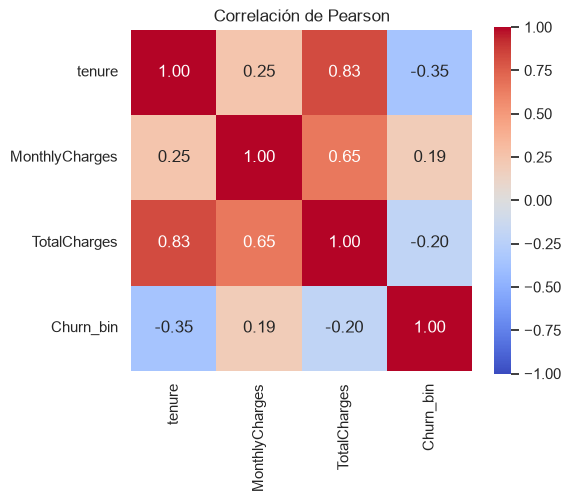

In [32]:
corr_df = df[num_cols].copy()
corr_df["Churn_bin"] = (df[TARGET] == "Yes").astype(int)
corr = corr_df.corr(method="pearson")

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlación de Pearson")
plt.show()

**Lectura:** `TotalCharges` está fuertemente correlacionada con `tenure` (~0,83) y moderadamente con `MonthlyCharges`. Esto es esperable, ya que `TotalCharges ≈ tenure × MonthlyCharges`. Existe **redundancia parcial**. No se elimina automáticamente: se decidirá en modelado según el algoritmo (los modelos lineales son sensibles a la multicolinealidad; los basados en árboles, mucho menos). `tenure` es la más asociada con `Churn` (correlación negativa).

In [33]:
# Multicolinealidad: VIF sobre las variables numéricas
X = df[num_cols].dropna()
X = (X - X.mean()) / X.std()
corr_x = np.linalg.inv(np.corrcoef(X.values, rowvar=False))
pd.Series(np.diag(corr_x), index=num_cols, name="VIF").round(2).to_frame()

,VIF
tenure,5.84
MonthlyCharges,3.23
TotalCharges,9.53


**Categóricas:** asociación con `Churn` mediante V de Cramér (0 = sin asociación, 1 = asociación perfecta).

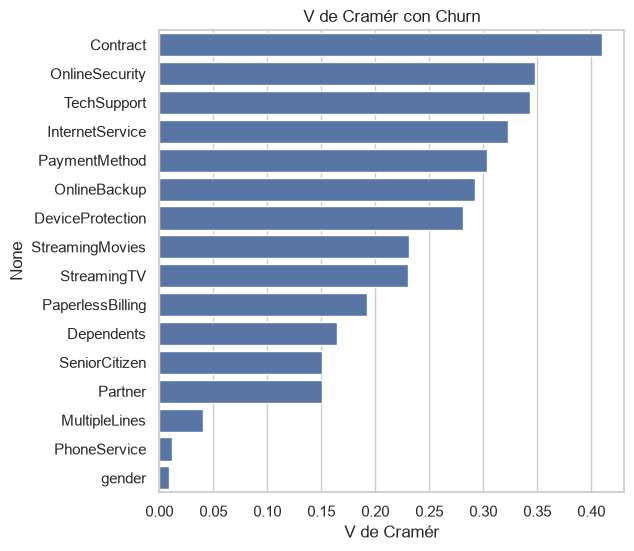

,V de Cramér
Contract,0.410
OnlineSecurity,0.347
TechSupport,0.343
InternetService,0.322
PaymentMethod,0.303
OnlineBackup,0.292
DeviceProtection,0.282
StreamingMovies,0.231
StreamingTV,0.231
PaperlessBilling,0.192


In [34]:
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla, correction=False)[0]
    n = tabla.values.sum()
    r, k = tabla.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

v_target = pd.Series({c: cramers_v(df[c], df[TARGET]) for c in cat_cols}).sort_values(ascending=False)
plt.figure(figsize=(6, 6))
sns.barplot(x=v_target.values, y=v_target.index)
plt.title("V de Cramér con Churn"); plt.xlabel("V de Cramér")
plt.show()
v_target.round(3).to_frame("V de Cramér")

In [35]:
# Redundancia entre categóricas: pares con asociación alta
pares = []
for i, a in enumerate(cat_cols):
    for b in cat_cols[i+1:]:
        pares.append((a, b, cramers_v(df[a], df[b])))
pares = pd.DataFrame(pares, columns=["var_1", "var_2", "cramers_v"]).sort_values("cramers_v", ascending=False)
pares.head(10).round(3)

,var_1,var_2,cramers_v
54,PhoneService,MultipleLines,1.000
110,StreamingTV,StreamingMovies,0.771
101,DeviceProtection,StreamingMovies,0.736
100,DeviceProtection,StreamingTV,0.734
86,OnlineSecurity,TechSupport,0.733
99,DeviceProtection,TechSupport,0.726
75,InternetService,OnlineSecurity,0.724
78,InternetService,TechSupport,0.723
93,OnlineBackup,TechSupport,0.720
92,OnlineBackup,DeviceProtection,0.719


**Lectura:** las variables más asociadas con `Churn` son `Contract`, `OnlineSecurity`, `TechSupport`, `InternetService` y `PaymentMethod`; `gender` y `PhoneService` son las menos informativas. Entre predictoras, los servicios de internet (`OnlineSecurity`, `StreamingTV`, etc.) comparten información con `InternetService` por la categoría `No internet service`, lo que confirma la redundancia mencionada.

### 3.8 Valores atípicos

In [36]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()

pd.Series({c: iqr_outliers(df[c].dropna()) for c in num_cols}, name="outliers (regla IQR)").to_frame()

,outliers (regla IQR)
tenure,0
MonthlyCharges,0
TotalCharges,0


**Lectura:** las tres variables numéricas tienen rangos plausibles (`tenure` 0–72 meses, cargos sin valores negativos) y prácticamente no presentan atípicos según la regla del IQR. No se justifica ningún tratamiento de outliers.

## Conclusiones del análisis exploratorio (insumos para las siguientes ramas)

1. **Datos:** 7.043 clientes, 21 columnas, sin duplicados; `customerID` es solo un identificador y se excluye.
2. **Faltantes:** solo `TotalCharges` (11 registros, 0,156 %), todos con `tenure = 0` → faltante con significado; proponer imputar 0.
3. **Objetivo desbalanceado (~26/74):** usar división estratificada y métricas como F1, recall y ROC-AUC.
4. **Variables más informativas:** `Contract`, `tenure`, `InternetService`, `OnlineSecurity`, `TechSupport`, `PaymentMethod`, `MonthlyCharges`.
5. **Poco informativas:** `gender`, `PhoneService`.
6. **Redundancia:** `TotalCharges` con `tenure` y `MonthlyCharges`; categorías `No internet service` / `No phone service` duplican información. Decidir según el modelo.
7. **Fuga de información:** en esta sección solo se convirtió un tipo de dato y no se imputó ni escaló nada; todo lo que aprenda de los datos se ajustará solo con entrenamiento.

---
*Continúa en la rama `feature/preprocesamiento`: limpieza, codificación, escalamiento y separación entrenamiento/prueba.*

## 4. Preparación de los datos

### 4.1 Tratamiento de valores faltantes
El EDA identificó **11 faltantes en `TotalCharges` (≈ 0,156 %)** y mostró que **todos corresponden a clientes con `tenure = 0`**, es decir, clientes recién registrados que todavía no han recibido su primera factura. No son faltantes aleatorios: el total acumulado es 0 por construcción.

- **Estrategia elegida: imputación con constante 0** (`SimpleImputer(strategy='constant', fill_value=0)`).
- **Por qué no la mediana:** imputar la mediana (≈ 1.398) asignaría a un cliente que aún no ha pagado nada un gasto acumulado que no existe, y distorsionaría la relación `TotalCharges ≈ tenure × MonthlyCharges`.
- **Por qué no eliminar las filas:** son solo 11 registros, pero eliminarlos descarta clientes válidos sin necesidad, y el modelo tendría que predecir después sobre clientes nuevos con `tenure = 0`.
- **Fuga de información:** un valor constante no se calcula a partir de los datos, por lo que no puede filtrar información del conjunto de prueba.

### 4.2 Otras decisiones de preparación
- **`customerID`**: se excluye (identificador único, sin valor predictivo).
- **`SeniorCitizen`**: el EDA la convirtió a `No`/`Yes`, por lo que se trata como categórica.
- **Valores atípicos:** el EDA (3.8) no encontró atípicos relevantes; no se aplica ningún tratamiento.
- **Variables nuevas:** no se crean en esta fase.
- **Redundancia (`TotalCharges` con `tenure` y `MonthlyCharges`; categorías `No internet service` / `No phone service`):** se conservan todas. La redundancia entre variables es un problema para modelos lineales, pero no impide entrenar; se revisará en la etapa de modelado según el algoritmo elegido.

### 4.3 Separación entrenamiento/prueba
- **80 % entrenamiento / 20 % prueba** con `train_test_split`, **estratificada por `Churn`** (mantiene la proporción de clases ~26/74) y `random_state=42`.
- La separación se hace **antes** de ajustar cualquier transformación.
- **Grupos:** cada fila es un cliente distinto (`customerID` tiene 7.043 valores únicos, ver 3.1), así que no hay observaciones repetidas que puedan quedar en ambos conjuntos. Una separación aleatoria estratificada no genera fuga por grupos.

### 4.4 Transformaciones (pipeline)
- Numéricas (`tenure`, `MonthlyCharges`, `TotalCharges`): imputación con 0 + `StandardScaler`.
- Categóricas: `OneHotEncoder(handle_unknown='ignore')`.
- Todo va dentro de un `ColumnTransformer` (`preprocessor`), que se ajusta (`fit`) solo con entrenamiento y se aplica (`transform`) a prueba.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Asegurar tipos correctos y quitar el identificador (por si el EDA no lo hizo)
df = df.drop(columns=['customerID'], errors='ignore')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Variables predictoras y objetivo
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

# Separación ANTES de cualquier transformación (evita fuga de información)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Entrenamiento: {X_train.shape} | Prueba: {X_test.shape}")
print(f"Proporción de Churn en train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")
print("Faltantes en train:", X_train.isnull().sum().sum(),
      "| en test:", X_test.isnull().sum().sum())

# Tipos de variables
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [c for c in X.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

Entrenamiento: (5634, 19) | Prueba: (1409, 19)
Proporción de Churn en train: 0.265 | test: 0.265
Faltantes en train: 8 | en test: 3


### 4.5 Verificación del preprocesamiento
Se comprueba que el `preprocessor` se ajusta solo con entrenamiento, que no quedan valores faltantes y que las columnas de prueba coinciden con las de entrenamiento. Esta celda es solo una verificación: el `preprocessor` se volverá a ajustar dentro del `Pipeline` del modelo.

In [38]:
import numpy as np

def _denso(m):
    return m.toarray() if hasattr(m, "toarray") else m

# Los faltantes originales: ¿a quiénes corresponden?
falt = X[X["TotalCharges"].isnull()]
print(f"Faltantes en TotalCharges: {len(falt)} | tenure de esos clientes: {[int(t) for t in sorted(falt['tenure'].unique())]}")

# Ajuste SOLO con entrenamiento
preprocessor.fit(X_train)
X_train_t = _denso(preprocessor.transform(X_train))
X_test_t = _denso(preprocessor.transform(X_test))

print("\nForma train transformado:", X_train_t.shape)
print("Forma test transformado :", X_test_t.shape)
print("NaN restantes -> train:", int(np.isnan(X_train_t).sum()), "| test:", int(np.isnan(X_test_t).sum()))
assert X_train_t.shape[1] == X_test_t.shape[1]
assert not np.isnan(X_train_t).any() and not np.isnan(X_test_t).any()

scaler = preprocessor.named_transformers_["num"].named_steps["scaler"]
print("\nMedias aprendidas SOLO con entrenamiento (para escalar):")
print({f: round(float(m), 2) for f, m in zip(numeric_features, scaler.mean_)})

Faltantes en TotalCharges: 11 | tenure de esos clientes: [0]

Forma train transformado: (5634, 46)
Forma test transformado : (1409, 46)
NaN restantes -> train: 0 | test: 0

Medias aprendidas SOLO con entrenamiento (para escalar):
{'tenure': 32.49, 'MonthlyCharges': 64.93, 'TotalCharges': 2299.33}


### 4.6 Prevención de fuga de información
- El **conjunto de prueba no interviene** en ninguna decisión de preparación: la separación se hace antes de ajustar transformaciones.
- El escalamiento y la codificación están dentro de un `ColumnTransformer` que se ajusta (`fit`) solo con `X_train` y solo se aplica (`transform`) a `X_test`. La imputación es una constante (0), fijada por el significado de la variable y no calculada con los datos.
- La variable objetivo `Churn` **no se usa como predictora** (se separa en `y` antes de construir `X`).
- `customerID` se excluye. Ninguna variable predictora contiene información posterior al evento que se predice (abandono del cliente): son datos de la cuenta y de los servicios contratados.
- Las exploraciones del EDA (correlación, V de Cramér, tasas de churn) se hicieron con fines descriptivos y **no** alimentan ninguna transformación del modelo.
- Al ser un pipeline, la validación cruzada o el ajuste de hiperparámetros posteriores volverán a ajustar las transformaciones en cada partición, sin filtrar información entre particiones.

---
*Continúa en la rama `feature/modelo-base`: construir el modelo base (`DummyClassifier(strategy='most_frequent')`) con `X_train`, `X_test`, `y_train` y `y_test`, y luego el modelo predictivo usando el `preprocessor` definido arriba dentro de un `Pipeline`.*